In [12]:
from multi_llm_debate.analysis.correct_rate_by_round import (
    calculate_correct_rate_by_round,
)
from multi_llm_debate.analysis.classify_task_difficulty import (
    analyze_task_difficulty,
)
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_dir = Path("../data/bool_q/gemma2:2b(3)")
data_path = Path("../output/bool_q/processed_data.csv")

# Load dataset
dataframe = pd.read_csv(data_path)

# Analyze task difficulty
result_df = analyze_task_difficulty(model_dir, dataframe)

easy_df = result_df[result_df["difficulty"] == 0]
hard_df = result_df[result_df["difficulty"] == 1]
# Calculate correct rate by round
easy_correct_rate_by_round_df = calculate_correct_rate_by_round(
    dataframe=easy_df,
    model_dir=model_dir,
    max_round_number=10
)
hard_correct_rate_by_round_df = calculate_correct_rate_by_round(
    dataframe=hard_df,
    model_dir=model_dir,
    max_round_number=10
)
# Print the df
print("Easy Task Correct Rate by Round:")
print(easy_correct_rate_by_round_df.head())
print("\nHard Task Correct Rate by Round:")
print(hard_correct_rate_by_round_df.head())


Processing gemma2:2b(3): 100%|██████████| 2000/2000 [00:00<00:00, 4655.75it/s]

Easy Task Correct Rate by Round:
  model_configuration         0         1         2        3         4  \
0        gemma2:2b(3)  0.788512  0.917755  0.943211  0.95235  0.954961   

          5         6         7         8         9        10  
0  0.954961  0.955614  0.956266  0.956266  0.956266  0.956266  

Hard Task Correct Rate by Round:
  model_configuration    0         1         2         3         4         5  \
0        gemma2:2b(3)  0.0  0.128205  0.192308  0.211538  0.215812  0.220085   

          6         7         8         9        10  
0  0.224359  0.224359  0.224359  0.224359  0.224359  


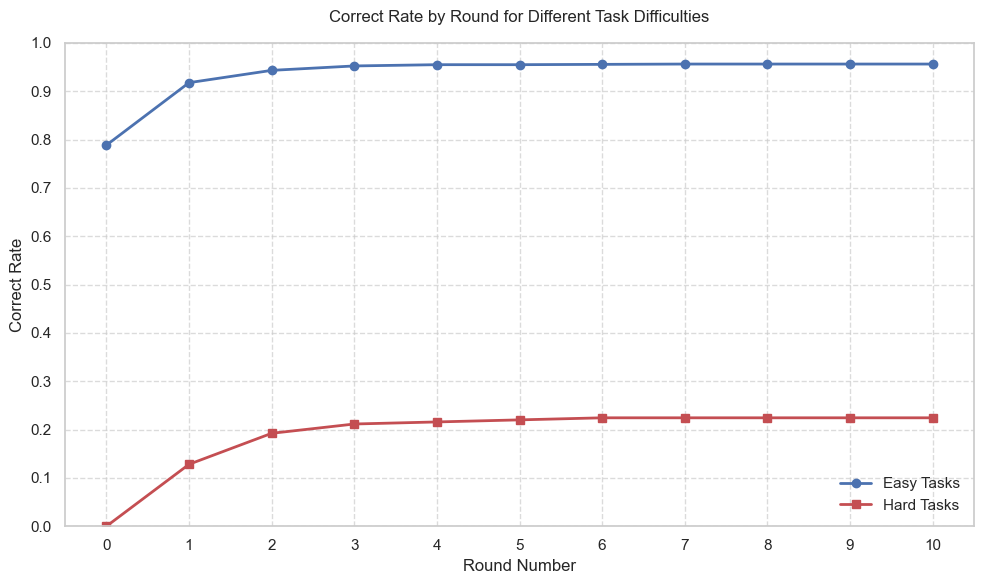

In [13]:
# Get numeric columns (rounds 0-10)
easy_rates = easy_correct_rate_by_round_df.iloc[0, 1:].values
hard_rates = hard_correct_rate_by_round_df.iloc[0, 1:].values
rounds = range(len(easy_rates))

# Create figure and axis
plt.figure(figsize=(10, 6))

# Plot both lines
plt.plot(rounds, easy_rates, 'b-o', label='Easy Tasks', linewidth=2)
plt.plot(rounds, hard_rates, 'r-s', label='Hard Tasks', linewidth=2)

# Customize plot
plt.title('Correct Rate by Round for Different Task Difficulties', pad=15)
plt.xlabel('Round Number')
plt.ylabel('Correct Rate')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# Set y-axis limits and ticks
plt.ylim(0, 1)
plt.yticks(np.arange(0, 1.1, 0.1))

# Set x-axis ticks
plt.xticks(rounds)

plt.tight_layout()
plt.show()